In [1]:
import pandas as pd  

In [2]:
import os  
os.getcwd()
# numpy pandas hadel data and sns anpd plt visualize it 

'C:\\Users\\Admin\\pandas'

In [3]:
# use value_counts  for categorical columns  

In [4]:
# “TextBlob is a Python library used for simple NLP tasks like sentiment analysis.
# It works using a lexicon-based approach, where each word has a predefined sentiment score.
# The text is first broken into words, then each word’s polarity is looked up in a dictionary, and finally an average score is calculated.
# The polarity ranges from -1 to +1, where negative means negative sentiment, positive means positive sentiment, and 0 means neutral.”

 # App Reviews Sentiment Analysis

App Reviews Sentiment Analysis means evaluating and understanding the sentiment expressed in user reviews of mobile applications.

In [5]:
df= pd.read_csv('C:\\Users\\Admin\\pandas\\linkedin-reviews - linkedin-reviews.csv')
df.head()

,Review,Rating
0,Does absolutely nothing for a LinkedIn beginne...,1
1,Force close(galaxy tab),1
2,Slow and it tries to upload your contacts with...,1
3,Add ability to customize the profile and move ...,4
4,"Good app, but it's a pain that it's not possib...",4


In [6]:
import  matplotlib.pyplot as  plt  
import  seaborn  as sns  

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  702 non-null    object
 1   Rating  702 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.1+ KB


# exploratory Data Analysis  
we will analyzing  the distribution of rating .it will  provide  insight into  the  overall 
sentiment of the  reviews.
then we can explore further such  as  analyzing the  length  of  reviews,
and  possible  derive  insights  from the text  of the  reviews 


# plotting  the  distribution  of  ratting  

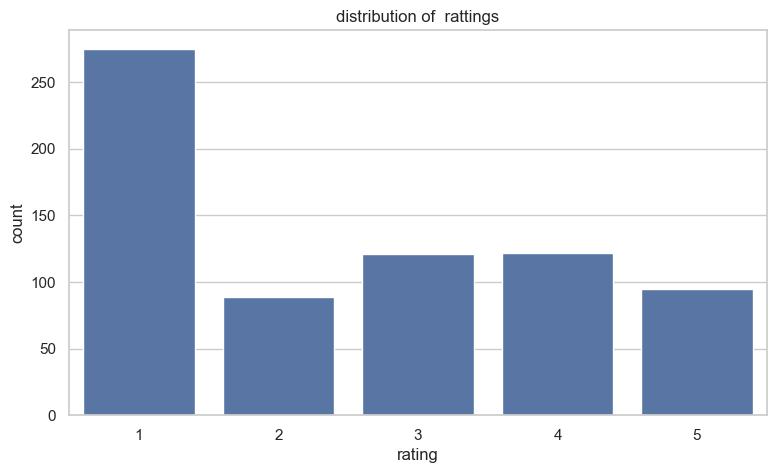

In [8]:
sns.set(style='whitegrid') # GRID  = Pixels in a grid do make an image
#  Pattern of arrangement = grid , Things being arranged = pixels , Final result = image

plt.figure(figsize=(9,5))
# =>It is just the size of the plot window
# X direction → left to right → width = 9
# Y direction → top to bottom → height = 5
sns.countplot(data = df,x='Rating')
#  It counts how many times each value appears in the Rating column
#  Then shows it as a bar chart
plt.title('distribution of  rattings')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()
# => Grid / plot is created in memory
# => plt.show() displays it on screen

# adding  sentiment label in the data  
we willl use  textblob library. textblob provides a  polarity scores raning from -1 (very  negative) to  1 (very possitive)
for  a given text. we can use this score  to classify each  reviews sentiment as  postive  ,negative  ,neutral.

In [9]:
! pip install Textblob

In [10]:
from textblob import TextBlob # textblob= module , TextBlob =  function hay  textblob module kaa 

In [11]:
def textblob_sentiment_analysis(review): # use for possitive  or negative  ,neeutral  review ,,so  we create function  here 
    sentiment  =  TextBlob(review).sentiment
    if   sentiment.polarity>0.1:
        return'Possitive'
    elif sentiment.polarity<-0.1:
        return'Negative'
    else:
        return'Neutral'
# 0.05 → Neutral
        

In [12]:
df['Sentiment'] = df['Review'].apply(textblob_sentiment_analysis) # apply textblob_sentiment_analysis function   on each  row  of  'review' column 
# No arguments → so  we not  use ()

In [13]:
df.sample(5)

,Review,Rating,Sentiment
238,Cant edit profile poor interface vs other soci...,3,Negative
48,Doesn't log in. FAIL,1,Negative
222,Make the X button larger,4,Neutral
402,"Latest update not working on my samsung epic, ...",1,Possitive
466,So unbelievable slow! It's actually faster on ...,1,Negative


# Analyzing App Reviews Sentiment

In [14]:
sentiment_distribution = df['Sentiment'].value_counts()   #  use  for  check  how many  positive aand  negative and  neutral  reviews
sentiment_distribution # precomputed values

Sentiment
Neutral      300
Possitive    295
Negative     107
Name: count, dtype: int64

In [15]:
x = sentiment_distribution.index
x# this gives labels (categories)

Index(['Neutral', 'Possitive', 'Negative'], dtype='object', name='Sentiment')

In [16]:
y=sentiment_distribution.values
y  # this  gives  values 

array([300, 295, 107])

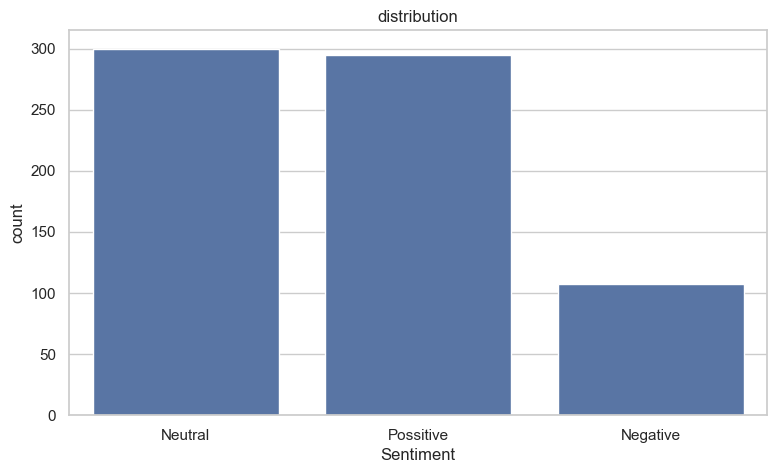

In [17]:
plt.figure(figsize=(9,5))
sns.barplot(x=sentiment_distribution.index,  #precomputed values pass in x  
            # “barplot is generally used for bivariate analysis, but it can also be used to visualize precomputed values like category counts.”
            y=sentiment_distribution.values)
plt.title('distribution')
plt.xlabel('Sentiment')
plt.ylabel('count')
plt.show()

# so,we can see  althrough the app  has  low rating, still the reviewers dont use  many  negative  word  in the  reviews  for the app 

next,we will explore the  relationship  between then  sentiment and the  ratting .this  analysis can
help  us  understand  whether there  is  a correlation  betweeen the sentiment of the text and numerical  
rating 

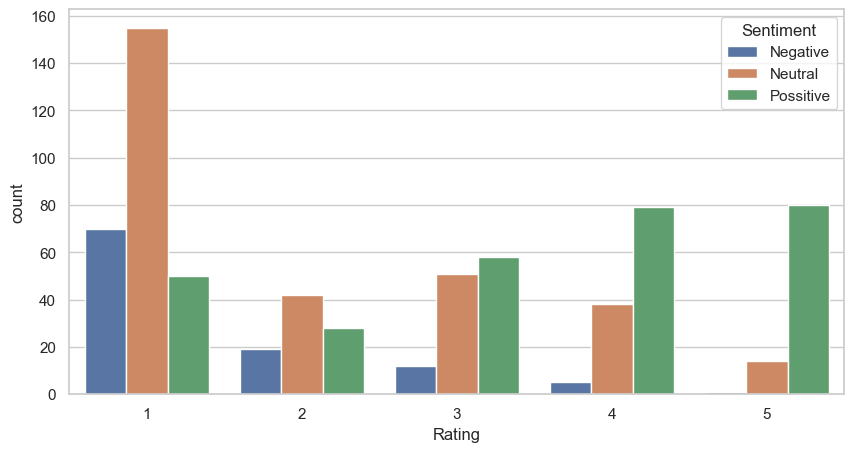

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(data = df,
              x = 'Rating',
              hue = 'Sentiment')
plt.xlabel('Rating')
plt.ylabel('count')
plt.legend(title = 'Sentiment')
plt.show()


# summary
App Reviews Sentiment Analysis is a valuable tool for app developers and business to understand user feedback, prioritize feature updates and 
maintain a positive user community. 
It involves using data analysis tchiniques to determine whether the sentiments in these reviews are positive, negative or neutral.

In [2]:


from textblob import TextBlob
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
text = "IlovePython.🔥Itisveryeasy."

blob = TextBlob(text)

# Sentiment
print(blob.sentiment)

# Words
print(blob.words)

# Sentences
print(blob.sentences)



Sentiment(polarity=0.0, subjectivity=0.0)
['IlovePython.🔥Itisveryeasy']
[Sentence("IlovePython.🔥Itisveryeasy.")]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:

# so  we should do  this  
# - Add spaces
# - Remove noise
# - Lowercase
# - Clean text

# then  pass to  textblob 
import re

text = "IlovePython 😊.Itisveryeasy."

# Add space after dot
text = re.sub(r'\.', '. ', text)

print(text)

blob = TextBlob(text)

# Sentiment
print(blob.sentiment)

# Words
print(blob.words)

# Sentences
print(blob.sentences)

IlovePython 😊. Itisveryeasy. 
Sentiment(polarity=0.0, subjectivity=0.0)
['IlovePython', '😊', 'Itisveryeasy']
[Sentence("IlovePython 😊."), Sentence("Itisveryeasy.")]


In [21]:
# unique(),bin in hist, dtT ambition box  and glass dor say  uthaa yaa hay  means  ?  

In [22]:
# this process we do now  is called report.
# dashbord  is  take all  visualization  and coonect  like sheet is called dash bord  

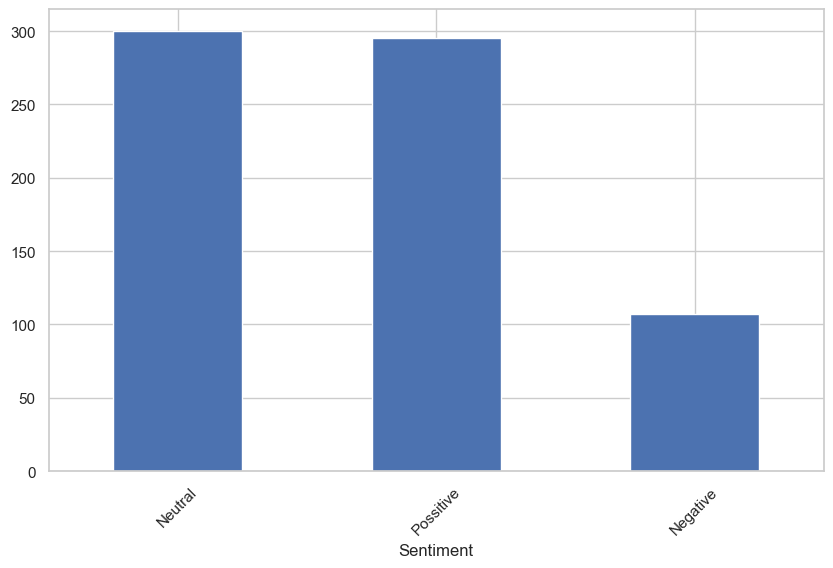

In [23]:
# Example: df['language']
df['Sentiment'].value_counts().plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

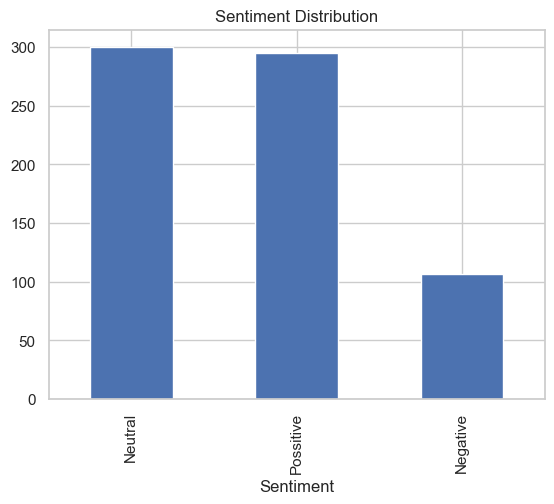

In [25]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.show()

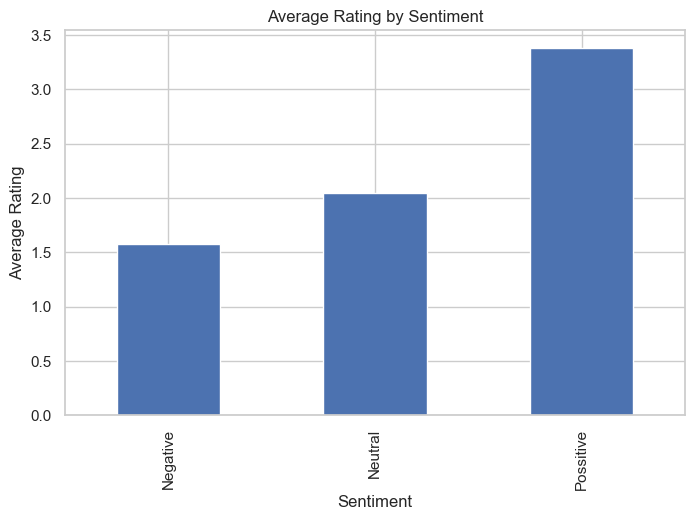

In [26]:
import matplotlib.pyplot as plt

# group and calculate average rating
avg_rating = df.groupby('Sentiment')['Rating'].mean()

# plot
plt.figure(figsize=(8,5))
avg_rating.plot(kind='bar')

plt.xlabel('Sentiment')
plt.ylabel('Average Rating')
plt.title('Average Rating by Sentiment')

plt.show()